CELL 1 — Install libraries

In [1]:
!pip install -q transformers==4.40.0 datasets scikit-learn accelerate

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.6/137.6 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 65.8 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 36.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 90.0 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 101.7 MB/s eta 0:00:0000:010:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
sentence-transformers 5.4.0 requires transformers<6.0.0,>=4.41.0, but you 

CELL 2 — Imports and config

In [2]:
import os, json, torch
import numpy as np
from datasets import load_dataset
from collections import Counter
from transformers import (
    RobertaTokenizer,
    RobertaForSequenceClassification,
    get_linear_schedule_with_warmup
)
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
import torch.nn as nn
from sklearn.metrics import classification_report, f1_score
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt

DEVICE   = torch.device("cuda" if torch.cuda.is_available() else "cpu")
EMOTIONS = ["joy","sadness","anger","fear","surprise","disgust","neutral"]
LABEL2ID = {e:i for i,e in enumerate(EMOTIONS)}
ID2LABEL = {i:e for i,e in enumerate(EMOTIONS)}

print(f"Device : {DEVICE}")
print(f"GPU    : {torch.cuda.get_device_name(0)}")
print(f"Emotions: {EMOTIONS}")

Device : cuda
GPU    : Tesla T4
Emotions: ['joy', 'sadness', 'anger', 'fear', 'surprise', 'disgust', 'neutral']


CELL 3 — Load GoEmotions dataset

In [3]:
# Dataset: GoEmotions by Google
# 58,000 Reddit comments labeled with 28 emotions
# We map 28 → 7 emotions
# No manual download needed — loads from HuggingFace automatically

print("Loading GoEmotions dataset from HuggingFace...")
raw = load_dataset("go_emotions", "simplified")

GO_LABELS = raw["train"].features["labels"].feature.names

# Map 28 original labels → 7 grouped emotions
GO_TO_7 = {
    "admiration":"joy","amusement":"joy","approval":"joy","caring":"joy",
    "desire":"joy","excitement":"joy","gratitude":"joy","joy":"joy",
    "love":"joy","optimism":"joy","pride":"joy","relief":"joy",
    "anger":"anger","annoyance":"anger","disapproval":"anger",
    "disgust":"disgust","embarrassment":"fear","fear":"fear",
    "nervousness":"fear","remorse":"sadness","sadness":"sadness",
    "grief":"sadness","disappointment":"sadness","surprise":"surprise",
    "realization":"surprise","confusion":"neutral","curiosity":"neutral",
    "neutral":"neutral"
}

def map_label(example):
    if len(example["labels"]) == 0:
        example["emotion"] = LABEL2ID["neutral"]
    else:
        original = GO_LABELS[example["labels"][0]]
        mapped   = GO_TO_7.get(original, "neutral")
        example["emotion"] = LABEL2ID[mapped]
    return example

print("Mapping 28 labels → 7 emotions...")
train_data = raw["train"].map(map_label)
val_data   = raw["validation"].map(map_label)
test_data  = raw["test"].map(map_label)

print(f"\nDataset sizes:")
print(f"  Train : {len(train_data)}")
print(f"  Val   : {len(val_data)}")
print(f"  Test  : {len(test_data)}")

dist = Counter(train_data["emotion"])
print(f"\nEmotion distribution in train:")
for eid, count in sorted(dist.items()):
    print(f"  {ID2LABEL[eid]:10s}: {count}")

Loading GoEmotions dataset from HuggingFace...


README.md: 0.00B [00:00, ?B/s]

simplified/train-00000-of-00001.parquet:   0%|          | 0.00/2.77M [00:00<?, ?B/s]

simplified/validation-00000-of-00001.par(…):   0%|          | 0.00/350k [00:00<?, ?B/s]

simplified/test-00000-of-00001.parquet:   0%|          | 0.00/347k [00:00<?, ?B/s]

...

Mapping 28 labels → 7 emotions...


Map:   0%|          | 0/43410 [00:00<?, ? examples/s]

Map:   0%|          | 0/5426 [00:00<?, ? examples/s]

Map:   0%|          | 0/5427 [00:00<?, ? examples/s]


Dataset sizes:
  Train : 43410
  Val   : 5426
  Test  : 5427

Emotion distribution in train:
  joy       : 16948
  sadness   : 2371
  anger     : 5336
  fear      : 863
  surprise  : 1449
  disgust   : 580
  neutral   : 15863


CELL 4 — Dataset class

In [4]:
class EmotionDataset(Dataset):
    def __init__(self, data, tokenizer, max_len=128):
        self.data      = data
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.data[idx]["text"],
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )
        return {
            "input_ids":      enc["input_ids"].squeeze(),
            "attention_mask": enc["attention_mask"].squeeze(),
            "label":          torch.tensor(self.data[idx]["emotion"], dtype=torch.long)
        }

CELL 5 — Load model and DataLoaders

In [5]:
print("Loading RoBERTa tokenizer and model...")
tokenizer = RobertaTokenizer.from_pretrained("roberta-base")
model     = RobertaForSequenceClassification.from_pretrained(
    "roberta-base",
    num_labels=7,
    id2label=ID2LABEL,
    label2id=LABEL2ID
)
model = model.to(DEVICE)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

BATCH_SIZE   = 32
train_loader = DataLoader(EmotionDataset(train_data, tokenizer),
                          batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(EmotionDataset(val_data,   tokenizer),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(EmotionDataset(test_data,  tokenizer),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# Class weights — fixes imbalance (joy has 14k, fear has 2k)
labels_arr     = np.array(train_data["emotion"])
class_weights  = compute_class_weight("balanced", classes=np.arange(7), y=labels_arr)
weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(DEVICE)

print("\nClass weights (balances imbalanced dataset):")
for e, w in zip(EMOTIONS, class_weights):
    print(f"  {e:10s}: {w:.3f}")

Loading RoBERTa tokenizer and model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Parameters: 124,651,015

Class weights (balances imbalanced dataset):
  joy       : 0.366
  sadness   : 2.616
  anger     : 1.162
  fear      : 7.186
  surprise  : 4.280
  disgust   : 10.692
  neutral   : 0.391


CELL 6 — Training setup

In [6]:
NUM_EPOCHS   = 4
LR           = 2e-5
criterion    = nn.CrossEntropyLoss(weight=weights_tensor)
optimizer    = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
total_steps  = len(train_loader) * NUM_EPOCHS
warmup_steps = int(total_steps * 0.1)
scheduler    = get_linear_schedule_with_warmup(
    optimizer, warmup_steps, total_steps
)
print(f"Total training steps : {total_steps}")
print(f"Warmup steps         : {warmup_steps}")
print(f"Epochs               : {NUM_EPOCHS}")

Total training steps : 5428
Warmup steps         : 542
Epochs               : 4


CELL 7 — Train and validate

In [7]:
def train_epoch(model, loader):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for batch in loader:
        ids    = batch["input_ids"].to(DEVICE)
        mask   = batch["attention_mask"].to(DEVICE)
        labels = batch["label"].to(DEVICE)
        optimizer.zero_grad()
        out  = model(input_ids=ids, attention_mask=mask)
        loss = criterion(out.logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
        correct    += (out.logits.argmax(-1) == labels).sum().item()
        total      += labels.size(0)
    return total_loss / len(loader), correct / total

def evaluate(model, loader):
    model.eval()
    total_loss, preds, trues = 0, [], []
    with torch.no_grad():
        for batch in loader:
            ids    = batch["input_ids"].to(DEVICE)
            mask   = batch["attention_mask"].to(DEVICE)
            labels = batch["label"].to(DEVICE)
            out    = model(input_ids=ids, attention_mask=mask)
            loss   = criterion(out.logits, labels)
            total_loss += loss.item()
            preds.extend(out.logits.argmax(-1).cpu().numpy())
            trues.extend(labels.cpu().numpy())
    f1 = f1_score(trues, preds, average="weighted")
    return total_loss / len(loader), f1, preds, trues

SAVE_PATH  = "/kaggle/working/emotion_model"
os.makedirs(SAVE_PATH, exist_ok=True)
best_f1    = 0.0
patience   = 2
no_improve = 0
history    = {"train_loss":[], "val_loss":[], "val_f1":[]}

print("Training started...\n" + "-"*65)
for epoch in range(NUM_EPOCHS):
    tr_loss, tr_acc        = train_epoch(model, train_loader)
    val_loss, val_f1, _, _ = evaluate(model, val_loader)

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(val_loss)
    history["val_f1"].append(val_f1)

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | "
          f"Train Loss: {tr_loss:.4f} | Acc: {tr_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val F1: {val_f1:.4f}")

    if val_f1 > best_f1:
        best_f1    = val_f1
        no_improve = 0
        model.save_pretrained(SAVE_PATH)
        tokenizer.save_pretrained(SAVE_PATH)
        print(f"  ✓ Best model saved (F1: {best_f1:.4f})")
    else:
        no_improve += 1
        print(f"  No improvement ({no_improve}/{patience})")
        if no_improve >= patience:
            print("  Early stopping triggered.")
            break

print(f"\nBest Val F1: {best_f1:.4f}")

Training started...
-----------------------------------------------------------------
Epoch 1/4 | Train Loss: 1.3591 | Acc: 0.5309 | Val Loss: 1.0531 | Val F1: 0.6844
  ✓ Best model saved (F1: 0.6844)
Epoch 2/4 | Train Loss: 0.9683 | Acc: 0.6654 | Val Loss: 1.0503 | Val F1: 0.6568
  No improvement (1/2)
Epoch 3/4 | Train Loss: 0.7851 | Acc: 0.7041 | Val Loss: 1.0566 | Val F1: 0.6668
  No improvement (2/2)
  Early stopping triggered.

Best Val F1: 0.6844


CELL 8 — Test report

In [8]:
from transformers import RobertaForSequenceClassification as RC
best_model = RC.from_pretrained(SAVE_PATH).to(DEVICE)
_, test_f1, test_preds, test_trues = evaluate(best_model, test_loader)

print("Final Test Classification Report:")
print(classification_report(test_trues, test_preds,
                            target_names=EMOTIONS, digits=4))

Final Test Classification Report:
              precision    recall  f1-score   support

         joy     0.8514    0.7668    0.8069      2054
     sadness     0.4956    0.5854    0.5367       287
       anger     0.4737    0.6273    0.5398       703
        fear     0.4409    0.6833    0.5359       120
    surprise     0.3498    0.4577    0.3966       201
     disgust     0.2540    0.7619    0.3810        84
     neutral     0.7460    0.6057    0.6685      1978

    accuracy                         0.6670      5427
   macro avg     0.5159    0.6412    0.5522      5427
weighted avg     0.7083    0.6670    0.6798      5427



CELL 9 — Save training plots

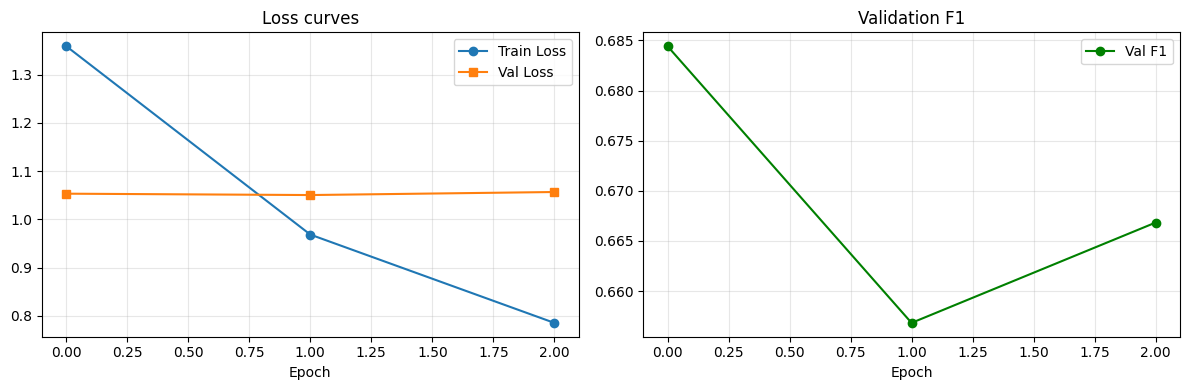

Curves saved.

Model saved at: /kaggle/working/emotion_model
Download emotion_model/ folder from Output tab before closing this notebook.


In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history["train_loss"], marker="o", label="Train Loss")
ax1.plot(history["val_loss"],   marker="s", label="Val Loss")
ax1.set_title("Loss curves"); ax1.set_xlabel("Epoch")
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(history["val_f1"], marker="o", color="green", label="Val F1")
ax2.set_title("Validation F1"); ax2.set_xlabel("Epoch")
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("/kaggle/working/training_curves.png", dpi=120)
plt.show()
print("Curves saved.")
print(f"\nModel saved at: {SAVE_PATH}")
print("Download emotion_model/ folder from Output tab before closing this notebook.")

CELL 10 — Quick inference test

In [10]:
def predict_emotion(text, model, tokenizer):
    model.eval()
    enc = tokenizer(text, return_tensors="pt",
                    max_length=128, truncation=True,
                    padding="max_length").to(DEVICE)
    with torch.no_grad():
        logits = model(**enc).logits
    probs      = torch.softmax(logits, dim=-1)[0]
    emotion    = ID2LABEL[probs.argmax().item()]
    confidence = probs.max().item()
    return emotion, round(confidence, 4)

tests = [
    "I went to class today and had lunch",
    "I am so happy about my results!",
    "I failed my exam and feel terrible",
    "I am furious at what happened",
    "I am terrified about tomorrow",
]
print("Quick inference test:\n")
for t in tests:
    emotion, conf = predict_emotion(t, best_model, tokenizer)
    print(f"  Text    : {t}")
    print(f"  Emotion : {emotion.upper()} ({conf})")
    print()

Quick inference test:

  Text    : I went to class today and had lunch
  Emotion : NEUTRAL (0.6639)

  Text    : I am so happy about my results!
  Emotion : JOY (0.9464)

  Text    : I failed my exam and feel terrible
  Emotion : FEAR (0.7333)

  Text    : I am furious at what happened
  Emotion : ANGER (0.7863)

  Text    : I am terrified about tomorrow
  Emotion : FEAR (0.9446)

